## VAE+Regression

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product
from sklearn.metrics import accuracy_score
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm


import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    # Code that might trigger warnings


In [2]:
!pip install optuna -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

## Training and test dataset  

In [111]:
sel_zone =  'IT_NORD'

df_features = pd.read_csv('lcpb_files/IT_NORD_VAE_input.csv') # vae training (input features X)
df_labels = pd.read_csv(f'lcpb_files/{sel_zone}_normalized_actuals_MSTL.csv') # regression training/test

df_labels

,date_time,solar,wind,hydro,generation,load,node_id,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00+00:00,0.0,2.0,1110.0,6894.0,10583.0,IT_NORD,0.000000,0.0,0.011976,0.099338
1,2022-01-01 01:00:00+00:00,0.0,22.0,1063.0,6297.0,10054.0,IT_NORD,0.000038,0.0,0.131732,0.095132
2,2022-01-01 02:00:00+00:00,0.0,22.0,1057.0,5373.0,9573.0,IT_NORD,0.000076,0.0,0.131728,0.094595
3,2022-01-01 03:00:00+00:00,0.0,22.0,1089.0,4963.0,9402.0,IT_NORD,0.000114,0.0,0.131724,0.097458
4,2022-01-01 04:00:00+00:00,0.0,22.0,1053.0,5405.0,9689.0,IT_NORD,0.000152,0.0,0.131720,0.094236
...,...,...,...,...,...,...,...,...,...,...,...
26371,2024-12-31 22:45:00+00:00,0.0,56.0,1216.0,10158.0,11958.0,IT_NORD,0.999848,0.0,0.265070,0.107815
26372,2024-12-31 23:00:00+00:00,0.0,8.0,218.0,2110.0,11528.0,IT_NORD,0.999886,0.0,0.037867,0.019329
26373,2024-12-31 23:15:00+00:00,0.0,8.0,214.0,2095.0,11695.0,IT_NORD,0.999924,0.0,0.037867,0.018974
26374,2024-12-31 23:30:00+00:00,0.0,7.0,202.0,2170.0,11553.0,IT_NORD,0.999962,0.0,0.033134,0.017910


In [112]:
# aggregate every 3h 
df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_labels = df_labels.set_index('date_time')
df_labels = df_labels.resample('3h').agg({
    'detrended_solar':'mean',
    'detrended_hydro':'mean',
    'detrended_wind':'mean' # consider all features normalized on surface and population
})
df_labels = df_labels.reset_index()
df_labels

,date_time,detrended_solar,detrended_hydro,detrended_wind
0,2022-01-01 00:00:00,0.000000,0.096355,0.091812
1,2022-01-01 03:00:00,0.000000,0.098472,0.129724
2,2022-01-01 06:00:00,0.012258,0.120070,0.071841
3,2022-01-01 09:00:00,0.092949,0.105125,0.125708
4,2022-01-01 12:00:00,0.063352,0.103514,0.125696
...,...,...,...,...
8763,2024-12-31 09:00:00,0.170923,0.106693,0.118335
8764,2024-12-31 12:00:00,0.110475,0.098949,0.184602
8765,2024-12-31 15:00:00,0.002080,0.207917,0.282426
8766,2024-12-31 18:00:00,0.000000,0.170559,0.298204


In [113]:
df_features

,Unnamed: 0,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,day_sin_t0,...,ws_100m_t8,hour_sin_t8,hour_cos_t8,day_sin_t8,day_cos_t8,month_sin_t8,month_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 00:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 03:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 06:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 09:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 15:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 21:00:00


# matching production of 1 day before

In [114]:
#Here we define the labels: (mean_solar, mean_wind, mean_hydro production) over the time window of 3 hours

df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['timestamp'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)

df_labels.set_index('date_time', inplace=True)

y_list = []

# for every row of df_features
for ts in df_features['timestamp']:
    # time window: from t to t + 3h , we will input meteo data of a 6h window and predict energy prodcution of the last 3h of that window
    window_start = ts + pd.Timedelta(hours=3)
    window_end = ts + pd.Timedelta(hours=6)

    # select production rows in this time window
    window_data = df_labels.loc[window_start:window_end]

    # determine the average in this window
    if not window_data.empty:
        mean_vals = window_data[['detrended_solar', 'detrended_wind', 'detrended_hydro']].mean().values
    else:
        mean_vals = [float('nan'), float('nan'), float('nan')]  # se non ci sono dati in quella finestra

    y_list.append(mean_vals)

y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind', 'mean_hydro'])
print(np.shape(y_df))
df_labels = y_df

(8320, 3)


## Matching timestamps (removing missing data)

In [108]:
# taking only rows that match timestamp between the dataframes
df_labels = y_df
df_common = pd.merge(df_labels, df_features, on='timestamp', how = 'inner')
df_labels = df_common[df_labels.columns]
df_features = df_common[df_features.columns]
print('shape of labels:',np.shape(df_labels))
print('shape of features:',np.shape(df_features))



KeyError: 'timestamp'

### Removing extra features and making the dataset

In [115]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t0','day_cos_t0',
           'day_sin_t1','day_cos_t1',
           'day_sin_t2','day_cos_t2',
           'day_sin_t3','day_cos_t3',
           'day_sin_t4','day_cos_t4',
           'day_sin_t5','day_cos_t5',
           'day_sin_t6','day_cos_t6',
           'day_sin_t7','day_cos_t7',
           'day_sin_t8','day_cos_t8',
           'month_sin_t0','month_cos_t0',
           'month_sin_t1','month_cos_t1',
           'month_sin_t2','month_cos_t2',
           'month_sin_t3','month_cos_t3',
           'month_sin_t4','month_cos_t4',
           'month_sin_t5','month_cos_t5',
           'month_sin_t6','month_cos_t6',
           'month_sin_t7','month_cos_t7',
           'month_sin_t8','month_cos_t8',
            'Unnamed: 0']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [116]:
df_features # methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,cos_dayofyear_t0,...,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 00:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-01 03:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-01 06:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-01 09:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-30 15:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-30 18:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 21:00:00


# Preparing the datasets

In [119]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# color information
info = [1 if x in range(7,19) else 2 for x in df_features['timestamp'].dt.hour]
# day = 1, night = 2

# Prepare inputs
features = df_features.drop(columns=['timestamp']).columns
X_array = df_features.drop(columns=['timestamp']).values  # VAE inputs

Y_array = df_labels[['mean_solar', 'mean_wind', 'mean_hydro']].values  # Regression targets
info_array = info.values if hasattr(info, "values") else np.array(info)  # Convert to array if needed

# Optional: Keep track of index or timestamps if needed later
index_array = df_features.index
timestamps = df_features['timestamp'].reset_index(drop=True)

# Split data (no shuffle to preserve time-order)
X_train, X_test, Y_train, Y_test, info_train, info_test, idx_train, idx_test = train_test_split(
    X_array, Y_array, info_array, index_array, test_size=0.2, shuffle=False
)

# Save timestamps for test predictions
test_timestamps = timestamps.loc[idx_test].reset_index(drop=True)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)
info_train_tensor = torch.tensor(info_train, dtype=torch.long)  # or torch.long if categorical
info_test_tensor = torch.tensor(info_test, dtype=torch.long)


# Create datasets including info vector
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor, info_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor, info_test_tensor)

# Create dataloaders as usual (shuffle only training)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [120]:
print(X_train_tensor.shape)
print(Y_train_tensor.shape)


torch.Size([6656, 90])
torch.Size([6656, 3])


# Model

In [121]:
# DNN for regression: inputs from the latent variables space of a VAE, outputs the solar, wind and hydro production over the chosen time-window

import optuna # to perform a grid search
import torch.optim as optim


class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,latent_dim, hidden_dim2, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.batch1 =  nn.BatchNorm1d(hidden_dim1)
        self.fc_mu = nn.Linear(hidden_dim1, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim1, latent_dim)

        # decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim2)
        self.batch2 =  nn.BatchNorm1d(hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h = self.activation((self.fc2(z)))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD

class Net(nn.Module):
    def __init__(self, z_dim, N1, N2, No, activation): 
        super(Net, self).__init__()
        self.fc1 = nn.Linear(z_dim, N1)
        self.fc2 = nn.Linear(N1, N2)
        self.out = nn.Linear(N2, No)  # No = number of regression outputs
        self.act = activation

    def forward(self, z):
        h1 = self.act(self.fc1(z))
        h2 = self.act(self.fc2(h1))
        output = self.out(h2)
        return output



# here we define the full network architecture for VAE+regression
class VAE_Regressor(nn.Module):
    def __init__(self, input_dim, hidden_dim1,
                 latent_dim, hidden_dim2,
                 vae_activation, N1, N2, No,
                 activation, lambda_tik):
        
        super(VAE_Regressor, self).__init__()

        self.vae = VAE(input_dim, hidden_dim1, latent_dim, hidden_dim2, vae_activation)
        self.regressor = Net(latent_dim, N1, N2, No, activation)
        self.criterion = nn.MSELoss()
        self.log_sigma_reg = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_vae = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        reconstructed_x, mu, logvar, z = self.vae(x)
        output = self.regressor(mu)  # pass only mu or z here
        return output, reconstructed_x, mu, logvar, z

    def VAE_loss(self, reconstructed_x, x, mu, logvar):
        return vae_loss(reconstructed_x, x, mu, logvar)

    def regression_loss(self, output, target):
        return self.criterion(output, target)

    def combined_loss(self, reg_loss, vae_loss):
        loss = (
            torch.exp(-2 * self.log_sigma_reg) * reg_loss +
            torch.exp(-2 * self.log_sigma_vae) * vae_loss +
            self.log_sigma_reg + self.log_sigma_vae
        )
        return loss

# Training code

In [122]:
def train(model, train_loader, optimizer, device, lambda_vae=1.0, epochs=100):
    model.train()
    
    losses = []
    vae_losses = []
    regr_losses = []
    
    for epoch in range(epochs):
        total_loss = 0.0
        total_vae_loss = 0.0
        total_regr_loss = 0.0

        for x_input, targets, info in train_loader:  # now only two elements per batch (info is useless in training)
            x_input = x_input.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            predictions, recon_x, mu, logvar, z = model(x_input)

            vae_loss_val, _, _ = model.VAE_loss(recon_x, x_input, mu, logvar)
            regr_loss_val = model.regression_loss(predictions, targets)

            loss = (1-lambda_vae) * regr_loss_val + lambda_vae * vae_loss_val

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            total_vae_loss += vae_loss_val.item()
            total_regr_loss += regr_loss_val.item()

        avg_loss = total_loss / len(train_loader)
        avg_vae_loss = total_vae_loss / len(train_loader)
        avg_regr_loss = total_regr_loss / len(train_loader)
        losses.append(avg_loss)
        vae_losses.append(avg_vae_loss)
        regr_losses.append(avg_regr_loss)

        print(f"Epoch [{epoch+1}/{epochs}] - Total: {avg_loss:.4f}, VAE: {avg_vae_loss:.4f}, Regr: {avg_regr_loss:.4f}")
    return losses, vae_losses, regr_losses
    

### Train code 

In [127]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 5
lambda_vae = 0.001

model = VAE_Regressor(
    input_dim=X_train_tensor.shape[1],     # input feature size
    hidden_dim1=64,                        # example, adjust as needed
    latent_dim=latent_dim,
    hidden_dim2=64,
    vae_activation=torch.relu,
    N1=8,
    N2=8,
    No=3,  # outputs: solar, wind, hydro
    activation=torch.relu,
    lambda_tik=1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

per_epoch_loss, per_epoch_vae_loss, per_epoch_regr_loss = train(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    device=device,
    lambda_vae= lambda_vae,    # weight for VAE loss, adjust as needed
    epochs=90         # number of epochs to train
)


Epoch [1/90] - Total: 2.3866, VAE: 2339.7373, Regr: 0.0469
Epoch [2/90] - Total: 1.6706, VAE: 1646.7442, Regr: 0.0239
Epoch [3/90] - Total: 1.7352, VAE: 1714.8663, Regr: 0.0204
Epoch [4/90] - Total: 1.4057, VAE: 1389.2488, Regr: 0.0164
Epoch [5/90] - Total: 1.4299, VAE: 1414.3519, Regr: 0.0156
Epoch [6/90] - Total: 1.3426, VAE: 1327.1209, Regr: 0.0155
Epoch [7/90] - Total: 1.3475, VAE: 1332.8542, Regr: 0.0147
Epoch [8/90] - Total: 1.6478, VAE: 1632.6081, Regr: 0.0152
Epoch [9/90] - Total: 1.2523, VAE: 1238.8179, Regr: 0.0135
Epoch [10/90] - Total: 1.4018, VAE: 1385.9055, Regr: 0.0159
Epoch [11/90] - Total: 1.2248, VAE: 1211.7252, Regr: 0.0131
Epoch [12/90] - Total: 1.2589, VAE: 1245.2597, Regr: 0.0137
Epoch [13/90] - Total: 1.3141, VAE: 1298.0031, Regr: 0.0161
Epoch [14/90] - Total: 1.1953, VAE: 1182.9091, Regr: 0.0124
Epoch [15/90] - Total: 1.2446, VAE: 1231.7060, Regr: 0.0129
Epoch [16/90] - Total: 1.2090, VAE: 1196.4311, Regr: 0.0126
Epoch [17/90] - Total: 1.1646, VAE: 1151.5264, Re

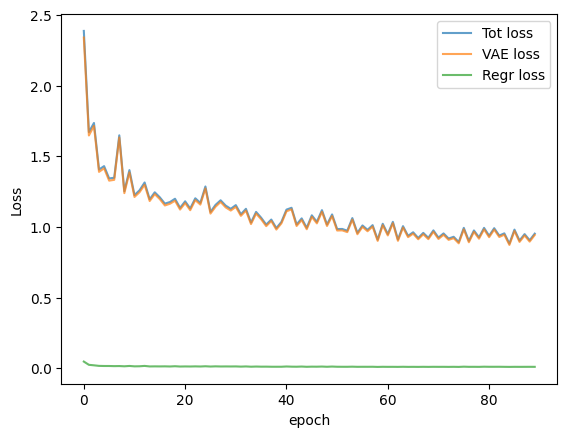

In [128]:
epochs = np.arange(0,len(per_epoch_loss),1)
per_epoch_vae_loss = lambda_vae*np.array(per_epoch_vae_loss)
plt.plot(epochs,per_epoch_loss, label = 'Tot loss', alpha = 0.7)
plt.plot(epochs,per_epoch_vae_loss, label = 'VAE loss', alpha = 0.7)
plt.plot(epochs,(1-lambda_vae)*np.array(per_epoch_regr_loss), label = 'Regr loss', alpha = 0.7)
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Visualizing latent space

explained variance: [0.34255087 0.24602792 0.176587   0.12794074 0.10689347]
(1664, 5)


<Figure size 750x500 with 0 Axes>

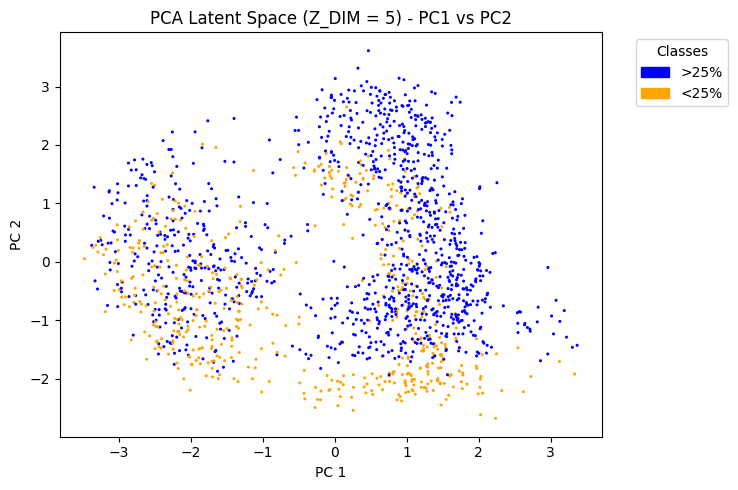

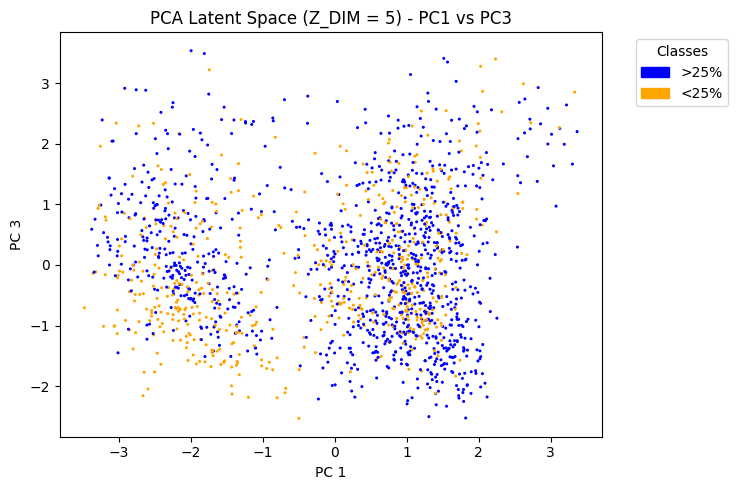

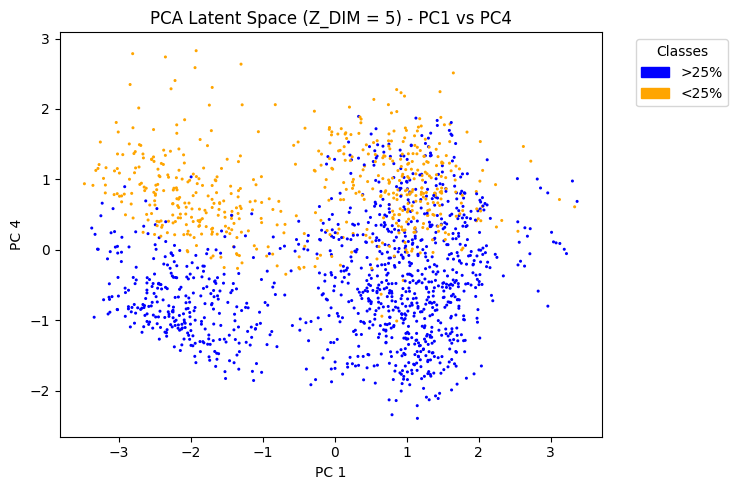

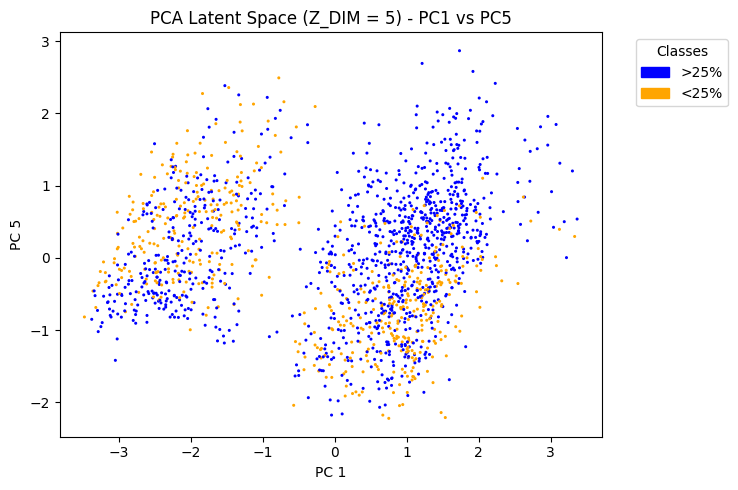

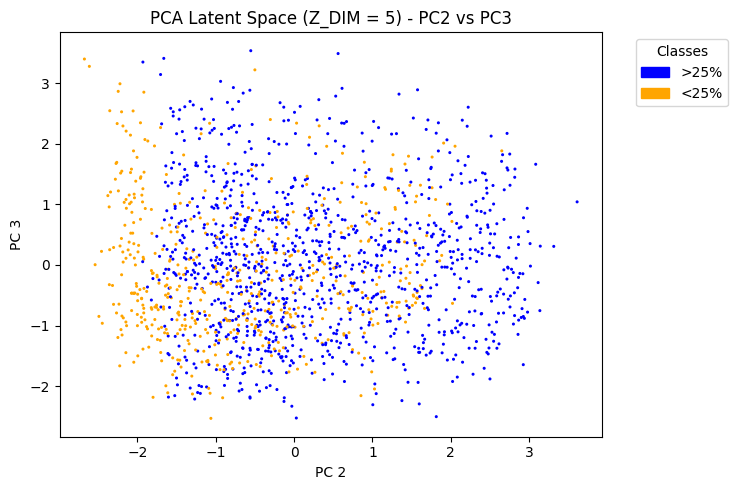

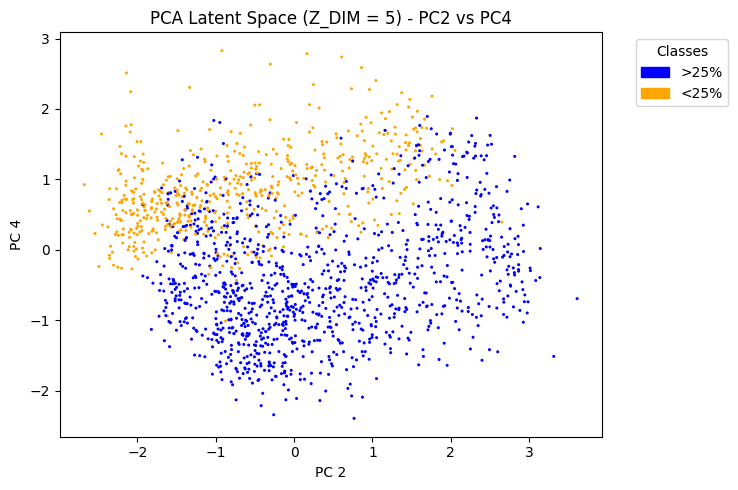

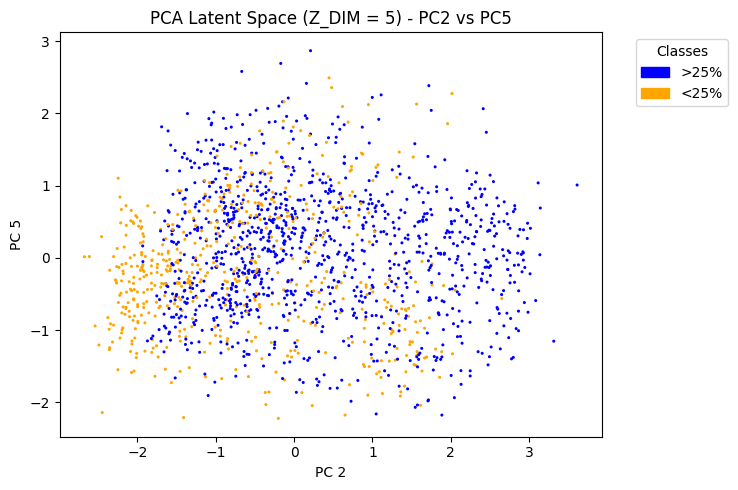

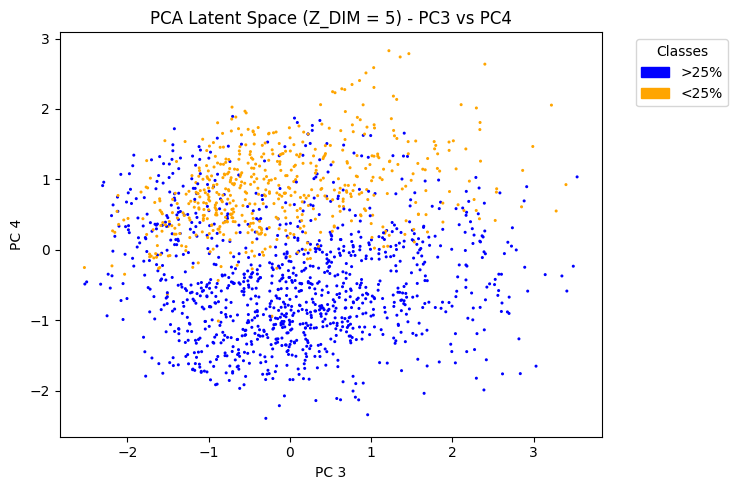

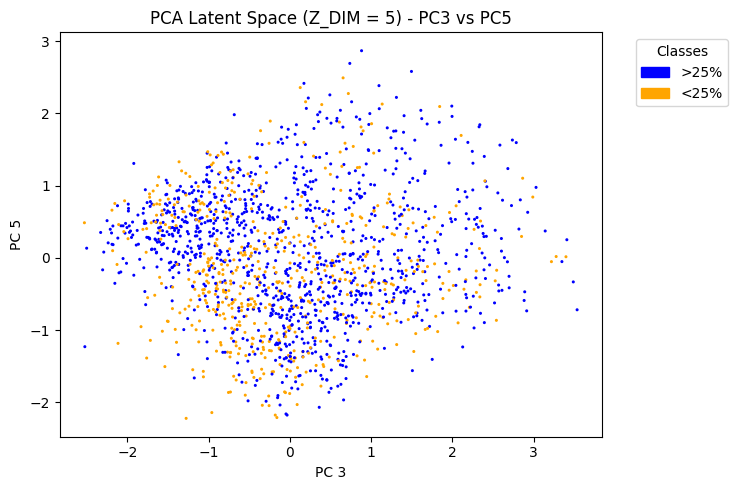

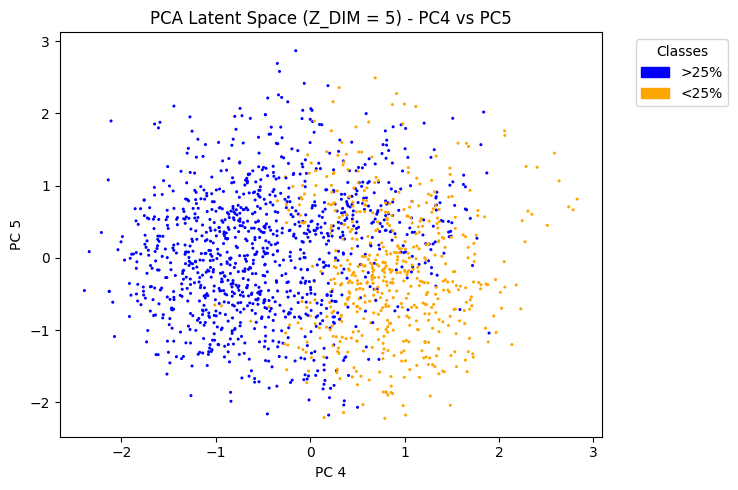

In [129]:

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import itertools

DEVICE = 'cpu'
# get the latent vectors (test set)
zs = []
ts = []
reconstructed = []
original = []

model.eval()
with torch.no_grad():
    # train set
    for x_train, _, t in test_loader:
        x_train = x_train.to(DEVICE)
        x_reconstructed, mu, logvar, z = model.vae(x_train)
        
        zs.append(z.cpu())  # vector
        ts.append(t)  # class information
        original.append(x_train.cpu().numpy())
        reconstructed.append(x_reconstructed.cpu().numpy())
        
zs = torch.cat(zs, dim=0)  # (total_samples, latent_dim)
zs = zs.numpy()          # convert to numpy array
ts = torch.cat(ts, dim=0)
ts = ts.numpy()

pca = PCA(n_components = latent_dim)
zs_pca = pca.fit_transform(zs)
print('explained variance:',pca.explained_variance_ratio_)

print(np.shape(zs_pca))
plt.figure(figsize = (7.5, 5))


############################
# SOFIA
# qui ci sono un paio di cose che dovresti ritoccare per i plot
# colors handling
unique_ts = np.unique(ts)
# vengono usati solo i primi n colori (dove n numero di diverse categorie in timestamp
custom_colors = ['blue','orange', 'green','#006064','lightblue','#1B5E20', 'green', 'brown','orange','yellow','pink','red','#FFEB3B','#FAF4C4','#FAF4C4',]  
keep_colors = custom_colors[:len(unique_ts)]
custom_colormap = ListedColormap(custom_colors[:len(unique_ts)])
# legend
# qui dovresti scrivere a mano a che cosa corrisponde ogni categoria
# custom_labels = ['winter','spring','summer','autumn']
custom_labels = ['>25%',
                 '<25%']
#############################
legend_handles = [
    Patch(color=keep_colors[i], label=custom_labels[i]) for i in range(len(unique_ts))
]

# Plot all 2D combinations of PCA components
combinations = list(itertools.combinations(range(zs_pca.shape[1]), 2))
Z_DIM = latent_dim
for i, (x_idx, y_idx) in enumerate(combinations):
    plt.figure(figsize=(7.5, 5))
    
    scatter = plt.scatter(zs_pca[:, x_idx], zs_pca[:, y_idx], c=ts, cmap=custom_colormap, s=1.4)
    
    plt.title(f"PCA Latent Space (Z_DIM = {Z_DIM}) - PC{x_idx+1} vs PC{y_idx+1}")
    plt.xlabel(f"PC {x_idx+1}")
    plt.ylabel(f"PC {y_idx+1}")
    
    plt.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
    #plt.colorbar(label='Generation trend')
    plt.tight_layout()
    
    #filename = f'{directory_name}/part2.0_latent_space_pca_{x_idx}_{y_idx}.png'
    #plt.savefig(filename)
    #plt.savefig(f"PCA_output/ZDIM_{Z_DIM}_PC{x_idx}_{y_idx}.png")
    plt.show()

### Visualizing the reconstructed data and the latent space

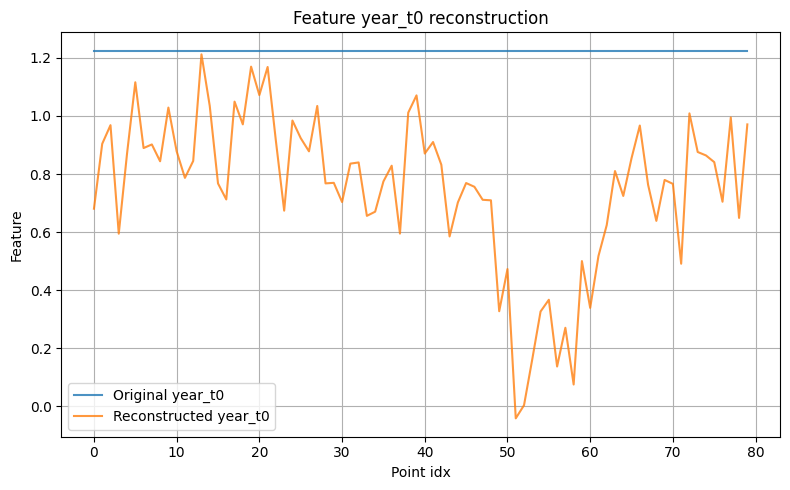

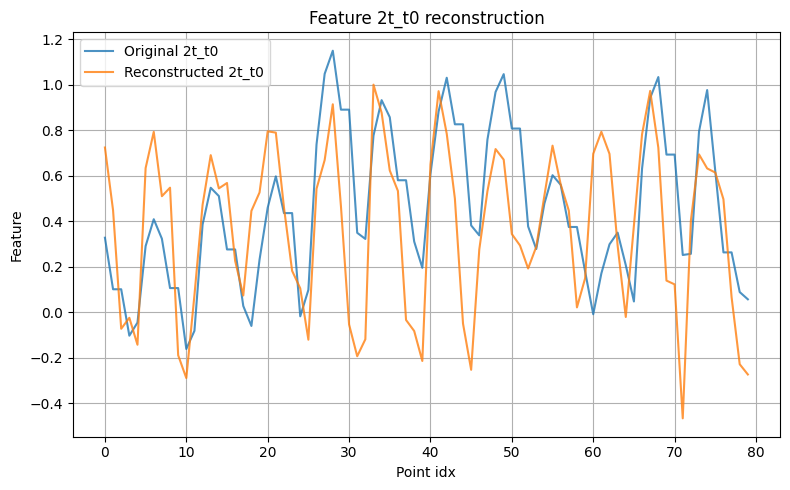

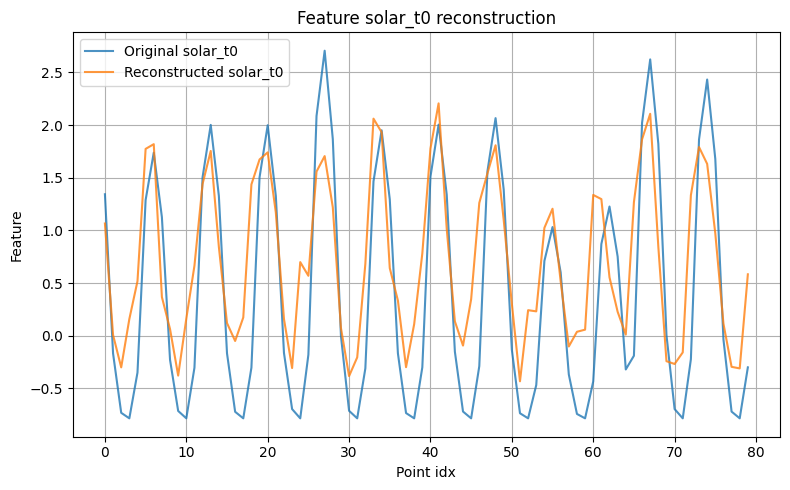

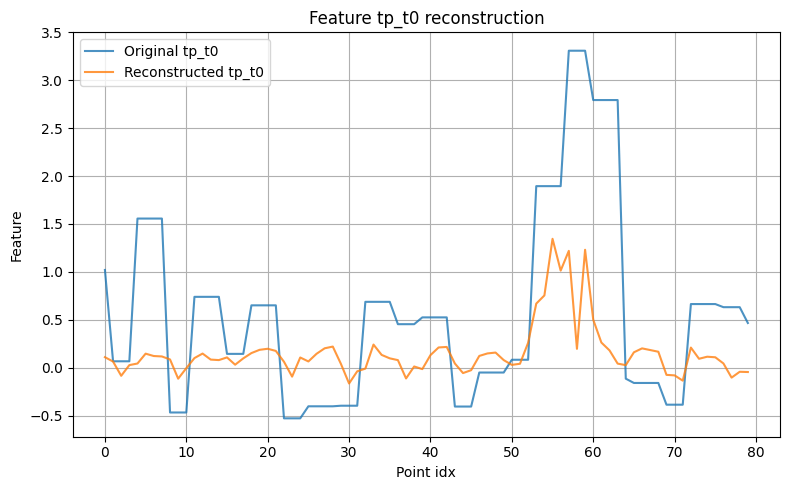

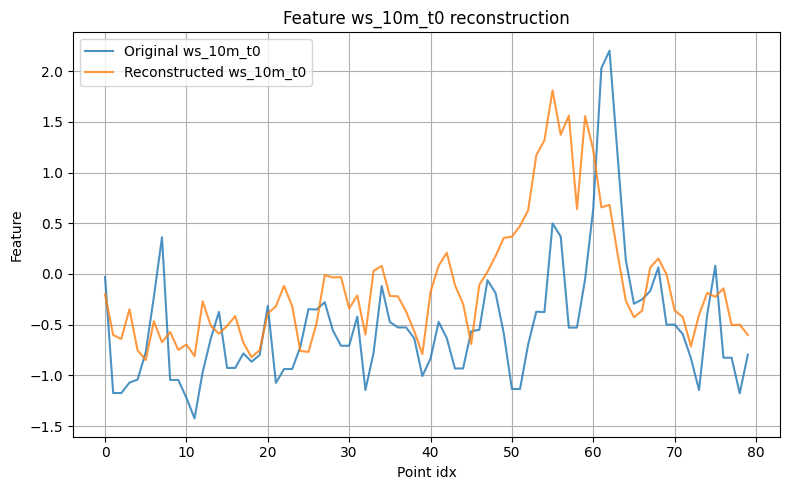

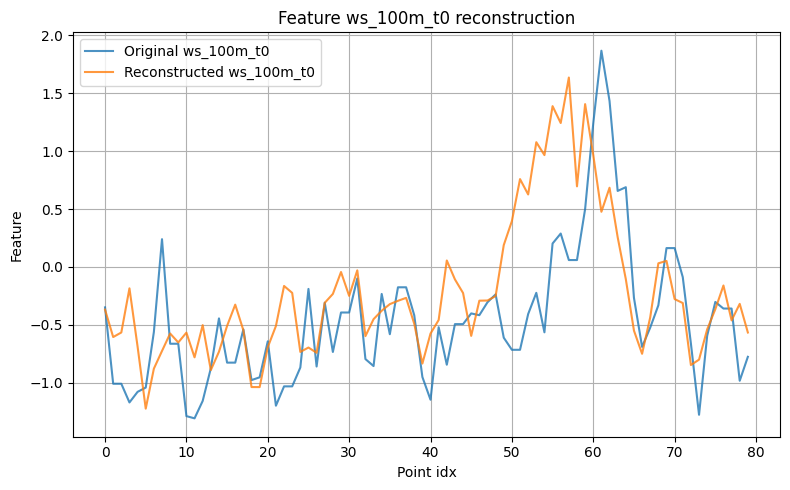

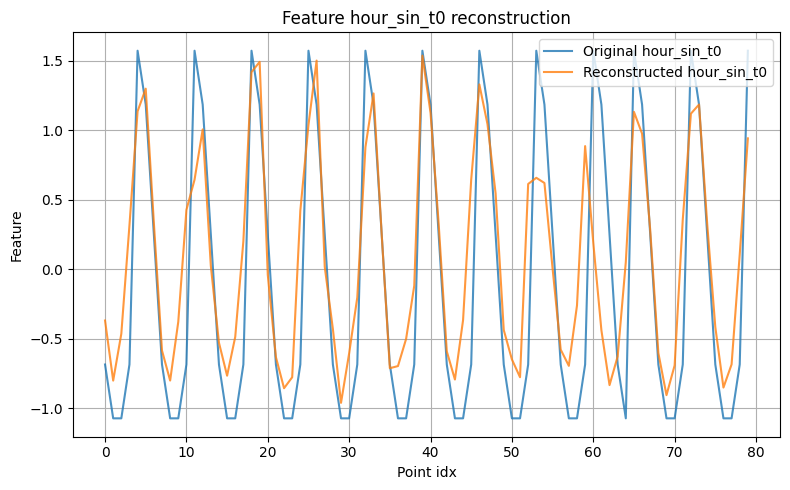

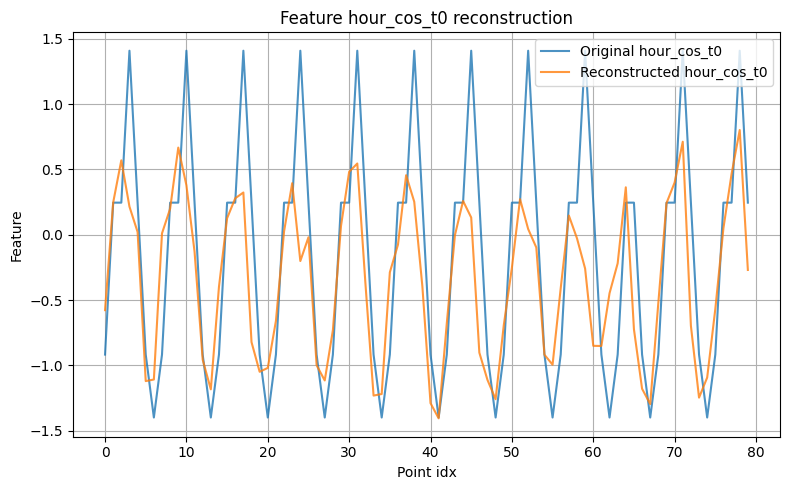

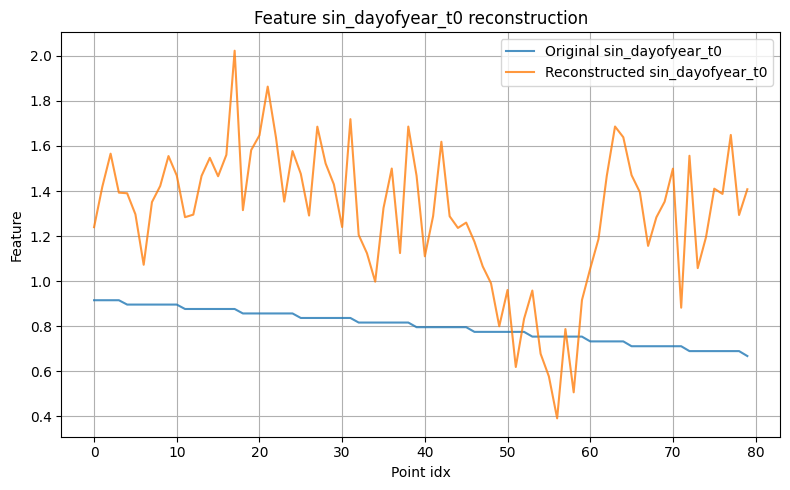

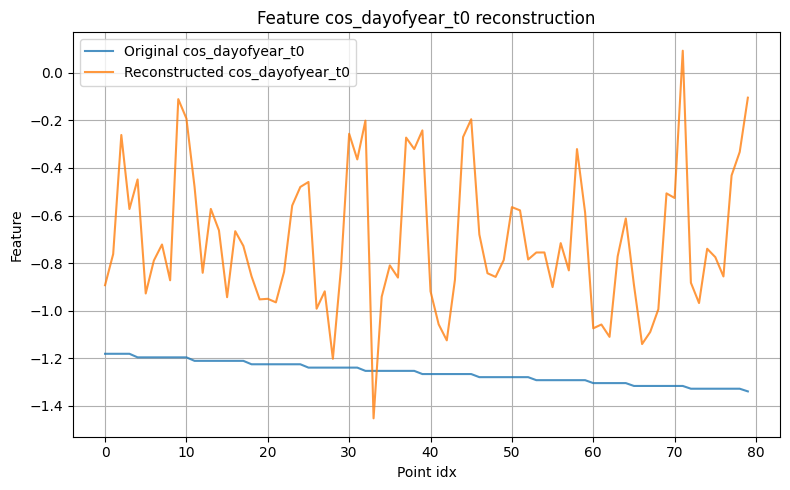

In [126]:
# concatenate all batches
original_all = np.concatenate(original, axis=0)       
reconstructed_all = np.concatenate(reconstructed, axis=0)
#print(np.shape(original_all),np.shape(reconstructed_all))
features_to_plot = [0,1,2,3,4,5,6,7,8,9]
dummy_x = np.arange(0,np.shape(original_all)[0],1)
points_to_plot = 80

for feature_idx in features_to_plot:
    
    plt.figure(figsize=(8, 5))
    plt.plot(dummy_x[:points_to_plot],
                original_all[:, feature_idx][:points_to_plot],
                alpha=0.8, label=f'Original {features[feature_idx]}')
    plt.plot(dummy_x[:points_to_plot],
                reconstructed_all[:, feature_idx][:points_to_plot],
                alpha=0.8, label=f'Reconstructed {features[feature_idx]}')
    plt.xlabel("Point idx")
    plt.ylabel("Feature")
    plt.title(f"Feature {features[feature_idx]} reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    #filename = f'{directory_name}/part2.2_feature_reconstruction_{feature_idx}.png'
    #plt.savefig(filename)
    plt.show() 

/tmp/ipykernel_4838/1537360569.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_test_tensor[:, i].cpu().numpy(), label='Original', fill=True)
/tmp/ipykernel_4838/1537360569.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_test_tensor[:, i].cpu().numpy(), label='Original', fill=True)


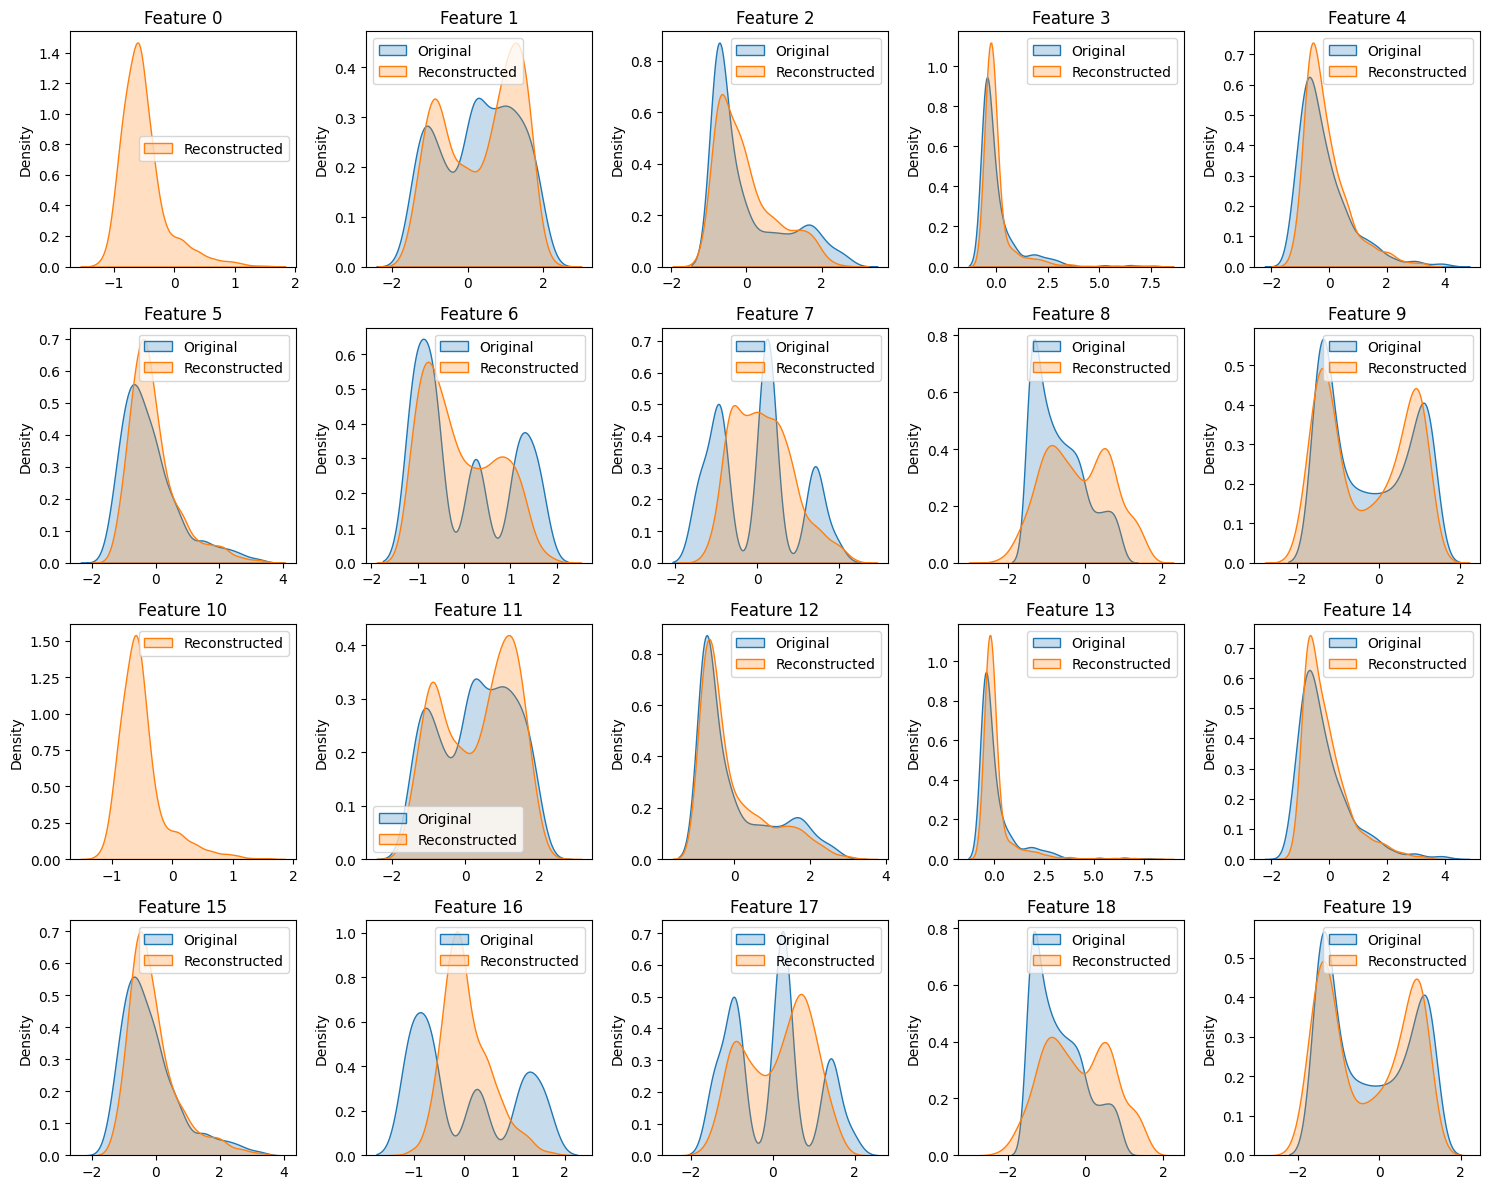

In [25]:
import seaborn as sns

num_features = X_test_tensor.shape[1]
plt.figure(figsize=(15, 12))
for i in range(num_features):
    plt.subplot(4, (num_features+1)//4, i+1)
    sns.kdeplot(X_test_tensor[:, i].cpu().numpy(), label='Original', fill=True)
    sns.kdeplot(reconstructed_x[:, i].cpu().numpy(), label='Reconstructed', fill=True)
    plt.title(f'Feature {i}')
    plt.legend()
plt.tight_layout()
plt.show()


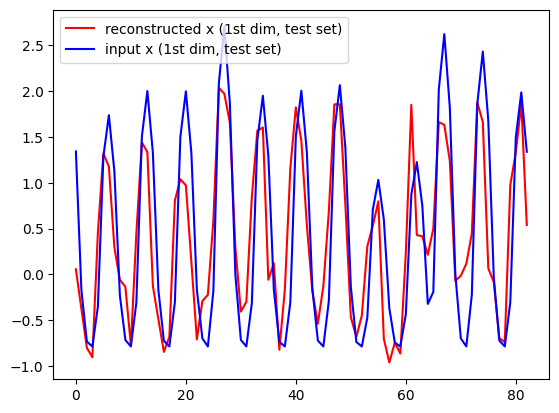

In [28]:


#Input reconstruction: visualization
plt.plot(np.arange(int(len(reconstructed_x)/20)),reconstructed_x[:int(len(reconstructed_x)/20),2],color='red',label='reconstructed x (1st dim, test set)')
plt.plot(np.arange(int(len(reconstructed_x)/20)),X_test[:int(len(reconstructed_x)/20),2],color='blue',label='input x (1st dim, test set)')
plt.legend()
plt.show()



In [39]:
test_vae_loss, recon_loss_test, kl_div_test = best_model.VAE_loss(
    reconstructed_x, X_test_tensor.to(device), mu, logvar)

test_regr_loss = best_model.regression_loss(
    Y_test_tensor, regr_output, best_params["lambda_tik"]
)

total_test_loss = best_params["beta"] * test_vae_loss + test_regr_loss

print(f"Test VAE Loss: {test_vae_loss.item():.4f}")
print(f"  - Reconstruction Loss: {recon_loss_test.item():.4f}")
print(f"  - KL Divergence: {kl_div_test.item():.4f}")
print(f"Test Regression Loss: {test_regr_loss.item():.4f}")

NameError: name 'mu' is not defined